
## 聚类 （无监督）
在数据在发现有意义组的过程

### 1.用于描述数据的聚类
在数据中探索所有可能有意义的组
- 市场营销，细分客户
- 文档聚类，自动将文档分到相似的主题的组
- 会话分组，web会话聚类

### 2.用于预处理的聚类
聚类输出的是每个样本的簇ID，可被用作其他数据科学任务的输入变量
- 用于降低维数
- 用于减少对象

### 3.聚类技术的类型
- 互斥或严格分区
- 重叠
- 层次
- 模糊或概率

### 4.聚类的算法分类
- 基于原型的聚类， k-means, 是一种通用实现
- 密度聚类， DBSCAN
- 层级聚类
- 基于模型的聚类

SOM， 可视化聚类技术，从神经网络和基于原型的聚类组合演变而来

### 5.聚类的通用实现k-means 
工作原理
(1) 初始化质心
(2) 分配数据点
(3) 计算新的质心
(4) 重新分配并计算新的质心
(5) 结束

### 6.DBSCAN
工作原理
(1) 定义ɛ(读作：epsilon)和最少点数量(MinPoints)；  
(2) 数据点的分类
(3) 聚类

### 7.SOM
工作原理
(1) 拓扑结构规范
(2) 初始化质心
(3) 计分配数据对象
(4) 质心更新
(5) 结束



In [1]:
import matplotlib.pyplot as plt

import platform

def set_chinese_font():
    system = platform.system()
    if system == 'Windows':
        plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
    elif system == 'Darwin':  # macOS
        plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti SC', 'Arial Unicode MS']
    else:  # Linux
        plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'Noto Sans CJK SC', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

set_chinese_font() 

In [ ]:
# 2. 从零实现K-Means

import numpy as np
from sklearn.datasets import make_blobs

class KMeans:
    def __init__(self, n_clusters=3, max_iters=100, random_state=42):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.random_state = random_state
        self.centroids = None
        self.labels = None
        
    def fit(self, X):
        """训练K-Means模型"""
        np.random.seed(self.random_state)
        
        # 1. 随机初始化质心
        n_samples = X.shape[0]
        random_indices = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.centroids = X[random_indices].copy()
        
        for i in range(self.max_iters):
            # 2. 分配每个点到最近的质心
            self.labels = self._assign_clusters(X)
            
            # 3. 保存旧的质心用于收敛判断
            old_centroids = self.centroids.copy()
            
            # 4. 更新质心
            self.centroids = self._update_centroids(X)
            
            # 5. 检查收敛（质心不再变化）
            if np.all(old_centroids == self.centroids):
                print(f"算法在第{i+1}轮收敛")
                break
                
        return self
    
    def _assign_clusters(self, X):
        """为每个样本分配簇标签"""
        n_samples = X.shape[0]
        distances = np.zeros((n_samples, self.n_clusters))
        
        # 计算每个样本到每个质心的距离
        for k in range(self.n_clusters):
            distances[:, k] = np.linalg.norm(X - self.centroids[k], axis=1)
        
        # 返回距离最近的质心的索引
        return np.argmin(distances, axis=1)
    
    def _update_centroids(self, X):
        """更新质心"""
        centroids = np.zeros((self.n_clusters, X.shape[1]))
        
        for k in range(self.n_clusters):
            # 获取属于第k簇的所有样本
            cluster_points = X[self.labels == k]
            
            if len(cluster_points) > 0:
                # 计算均值作为新质心
                centroids[k] = np.mean(cluster_points, axis=0)
            else:
                # 如果一个簇没有样本，重新随机初始化
                random_idx = np.random.choice(X.shape[0])
                centroids[k] = X[random_idx]
                
        return centroids
    
    def predict(self, X):
        """预测新样本的簇标签"""
        if self.centroids is None:
            raise ValueError("模型尚未训练，请先调用fit方法")
        
        distances = np.zeros((X.shape[0], self.n_clusters))
        for k in range(self.n_clusters):
            distances[:, k] = np.linalg.norm(X - self.centroids[k], axis=1)
        
        return np.argmin(distances, axis=1)
    
    def inertia(self, X):
        """计算惯量（簇内平方和）"""
        total_inertia = 0
        for k in range(self.n_clusters):
            cluster_points = X[self.labels == k]
            if len(cluster_points) > 0:
                distances = np.linalg.norm(cluster_points - self.centroids[k], axis=1)
                total_inertia += np.sum(distances ** 2)
        return total_inertia

算法在第3轮收敛


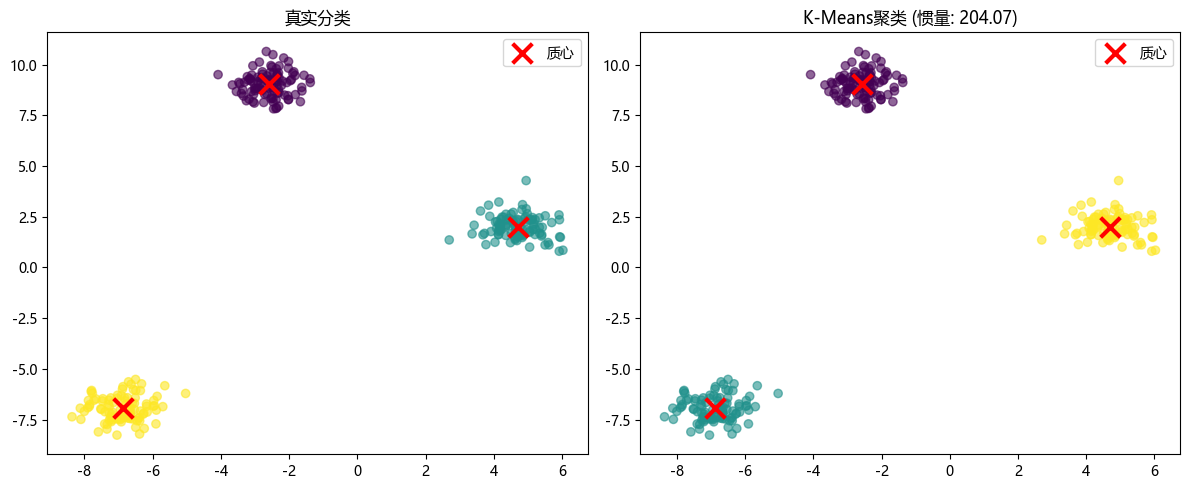

模型在300个样本上进行训练
簇分配统计: [100 100 100]


In [ ]:
# 3. 使用示例与可视化

# 生成测试数据
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=42)

# 训练模型
kmeans = KMeans(n_clusters=3, max_iters=100)
kmeans.fit(X)

# 获取预测结果
y_pred = kmeans.labels
centroids = kmeans.centroids

# 可视化结果
plt.figure(figsize=(12, 5))

# 左图：真实标签
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', alpha=0.6)
plt.scatter(centroids[:, 0], centroids[:, 1], 
           c='red', marker='x', s=200, linewidths=3, label='质心')
plt.title('真实分类')
plt.legend()

# 右图：K-Means预测
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', alpha=0.6)
plt.scatter(centroids[:, 0], centroids[:, 1], 
           c='red', marker='x', s=200, linewidths=3, label='质心')
plt.title(f'K-Means聚类 (惯量: {kmeans.inertia(X):.2f})')
plt.legend()

plt.tight_layout()
plt.show() # 颜色不一致是完全正常的，这仅仅是标签编号顺序的问题

print(f"模型在{len(X)}个样本上进行训练")
print(f"簇分配统计: {np.bincount(y_pred)}")

算法在第2轮收敛
算法在第2轮收敛
算法在第3轮收敛
算法在第5轮收敛
算法在第7轮收敛
算法在第8轮收敛
算法在第8轮收敛
算法在第13轮收敛
算法在第13轮收敛
算法在第13轮收敛


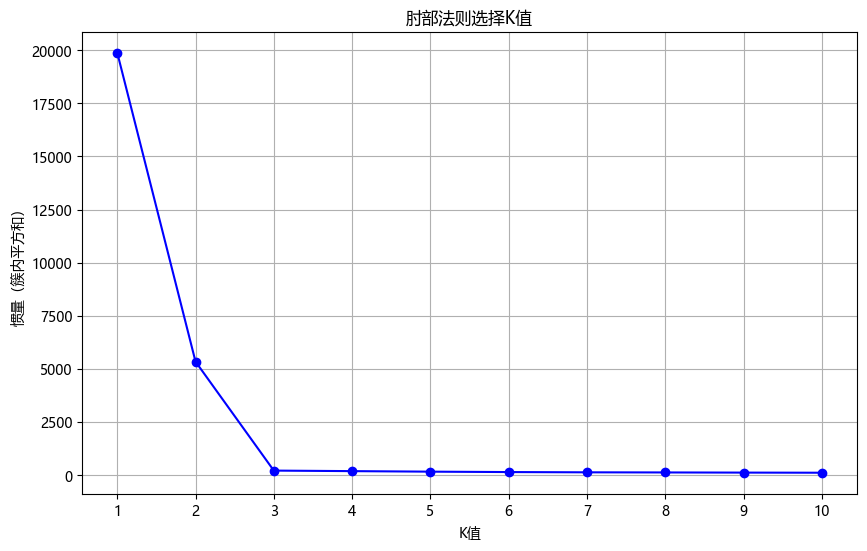

惯量下降率变化: [  2.83553422 203.99572388   1.01177451   1.3050934    1.55785559
   2.02174087   0.85085524   1.23878522]
通常选择下降率明显变缓的点作为最佳K值


In [6]:
def elbow_method(X, max_k=10):
    """使用肘部法则选择最佳K值"""
    inertias = []
    K_range = range(1, max_k + 1)
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, max_iters=100)
        kmeans.fit(X)
        inertias.append(kmeans.inertia(X))
    
    # 绘图
    plt.figure(figsize=(10, 6))
    plt.plot(K_range, inertias, 'bo-')
    plt.xlabel('K值')
    plt.ylabel('惯量（簇内平方和）')
    plt.title('肘部法则选择K值')
    plt.xticks(K_range)
    plt.grid(True)
    plt.show()
    
    return inertias

# 使用肘部法则
inertias = elbow_method(X, max_k=10)

# 计算相邻惯量下降率来辅助选择
diffs = np.diff(inertias)
diffs_ratio = diffs[:-1] / diffs[1:]  # 下降率变化
print(f"惯量下降率变化: {diffs_ratio}")
print("通常选择下降率明显变缓的点作为最佳K值")

1. 生成测试数据
数据形状: (300, 2)
样本数量: 300
特征数量: 2
真实簇数量: 3
各簇样本数: [100 100 100]

2. 训练K-Means模型
算法收敛迭代次数: 2
最终惯量: 204.07
各簇样本数: [100 100 100]
质心坐标:
[[-2.58361866  9.03185632]
 [-6.88217395 -6.94243433]
 [ 4.70421356  1.99562444]]

3. 可视化聚类结果


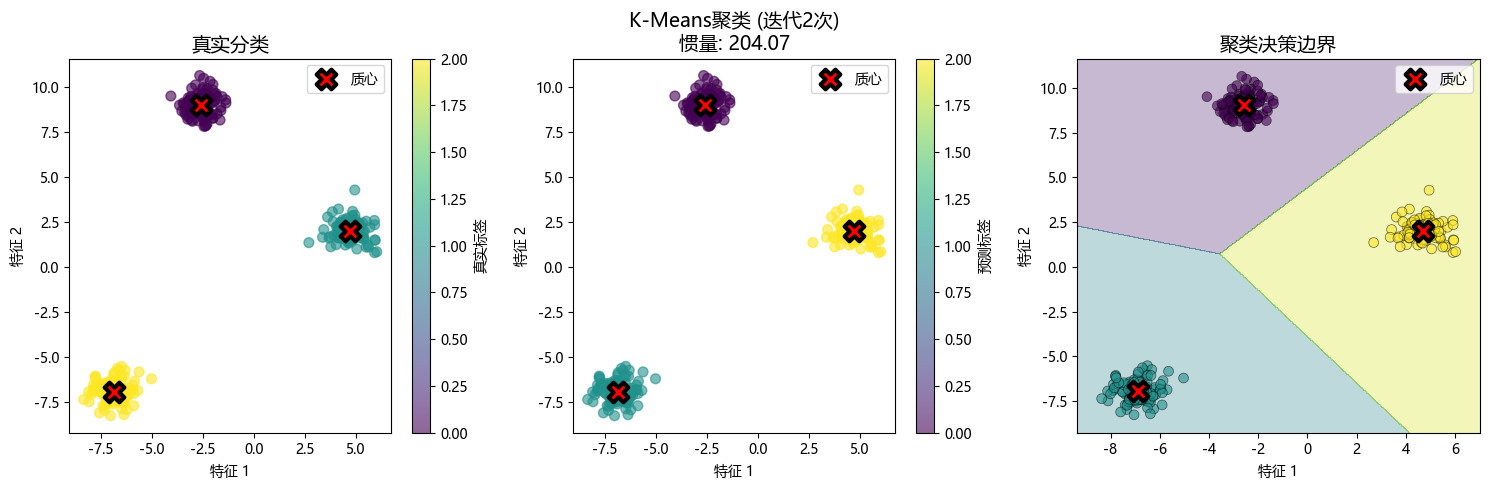


4. 评估聚类质量
调整兰德指数 (ARI): 1.0000
标准化互信息 (NMI): 1.0000
轮廓系数 (Silhouette): 0.9084

结果解读:
✓ ARI > 0.9: 完美的聚类！
✓ 轮廓系数 > 0.5: 簇内紧密，簇间分离良好

5. K-Means++ vs 随机初始化对比
随机初始化 - 平均惯量: 3360.01 ± 4247.30
K-Means++   - 平均惯量: 204.07 ± 0.00
改进: 16.47倍
稳定性提升: 149438550586601184.00倍

6. 肘部法则 - 选择最佳K值


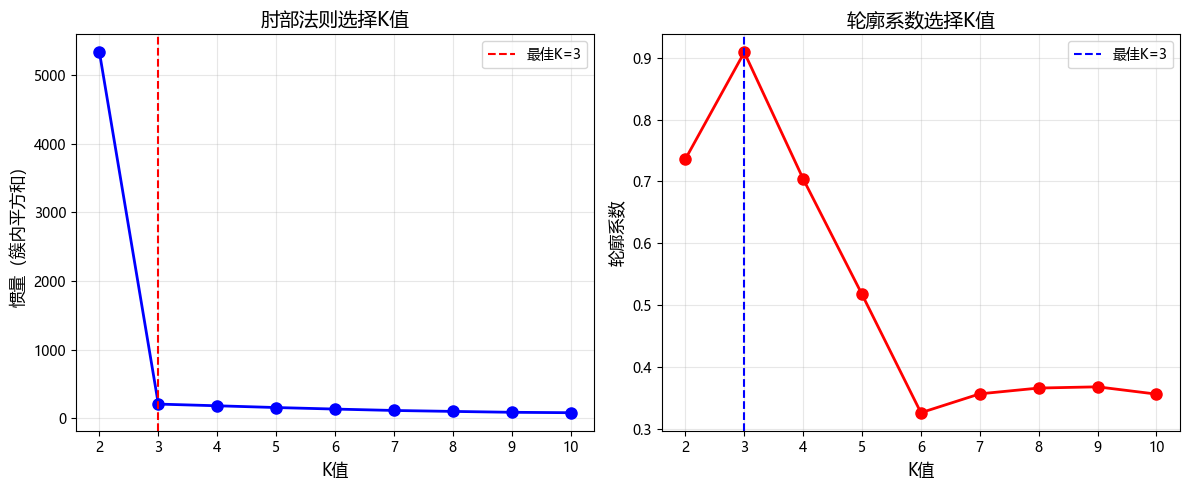


不同K值的评估结果:
K= 2 - 惯量:  5335.12, 轮廓系数: 0.7361
K= 3 - 惯量:   204.07, 轮廓系数: 0.9084
K= 4 - 惯量:   179.33, 轮廓系数: 0.7042
K= 5 - 惯量:   153.75, 轮廓系数: 0.5177
K= 6 - 惯量:   131.40, 轮廓系数: 0.3268
K= 7 - 惯量:   110.98, 轮廓系数: 0.3573
K= 8 - 惯量:    97.23, 轮廓系数: 0.3666
K= 9 - 惯量:    84.37, 轮廓系数: 0.3686
K=10 - 惯量:    78.34, 轮廓系数: 0.3568

总结: 使用sklearn的K-Means++实现完成聚类分析


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

# 1. 生成测试数据
print("="*50)
print("1. 生成测试数据")
print("="*50)

# 生成3个簇的数据
X, y_true = make_blobs(n_samples=300, centers=3, 
                       cluster_std=0.60, random_state=42)

print(f"数据形状: {X.shape}")
print(f"样本数量: {X.shape[0]}")
print(f"特征数量: {X.shape[1]}")
print(f"真实簇数量: {len(np.unique(y_true))}")
print(f"各簇样本数: {np.bincount(y_true)}")

# 2. 训练K-Means模型（默认使用K-Means++初始化）
print("\n" + "="*50)
print("2. 训练K-Means模型")
print("="*50)

# 创建K-Means模型
# init='k-means++' 是默认值，可以省略
# n_init=10 表示运行10次不同的初始化，选择最佳结果
kmeans = KMeans(n_clusters=3,           # 簇的数量
                init='k-means++',       # K-Means++初始化（默认）
                n_init=10,              # 初始化次数
                max_iter=300,           # 最大迭代次数
                random_state=42,        # 随机种子
                algorithm='lloyd')      # 算法类型

# 训练模型
kmeans.fit(X)

# 获取结果
y_pred = kmeans.labels_                 # 预测的簇标签
centroids = kmeans.cluster_centers_     # 质心坐标
inertia = kmeans.inertia_               # 惯量（簇内平方和）
n_iter = kmeans.n_iter_                 # 实际迭代次数

print(f"算法收敛迭代次数: {n_iter}")
print(f"最终惯量: {inertia:.2f}")
print(f"各簇样本数: {np.bincount(y_pred)}")
print(f"质心坐标:\n{centroids}")

# 3. 可视化结果
print("\n" + "="*50)
print("3. 可视化聚类结果")
print("="*50)

plt.figure(figsize=(15, 5))

# 左图：真实标签
plt.subplot(1, 3, 1)
scatter1 = plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', 
                       alpha=0.6, s=50)
plt.scatter(centroids[:, 0], centroids[:, 1], 
           c='red', marker='X', s=200, linewidths=3, 
           edgecolors='black', label='质心')
plt.title('真实分类', fontsize=14)
plt.xlabel('特征 1')
plt.ylabel('特征 2')
plt.legend()
plt.colorbar(scatter1, label='真实标签')

# 中图：K-Means预测
plt.subplot(1, 3, 2)
scatter2 = plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', 
                       alpha=0.6, s=50)
plt.scatter(centroids[:, 0], centroids[:, 1], 
           c='red', marker='X', s=200, linewidths=3,
           edgecolors='black', label='质心')
plt.title(f'K-Means聚类 (迭代{n_iter}次)\n惯量: {inertia:.2f}', fontsize=14)
plt.xlabel('特征 1')
plt.ylabel('特征 2')
plt.legend()
plt.colorbar(scatter2, label='预测标签')

# 右图：聚类边界（等高线图）
plt.subplot(1, 3, 3)

# 创建网格来绘制决策边界
h = 0.02  # 网格步长
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# 预测网格点的标签
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 绘制决策边界
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', 
           alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.scatter(centroids[:, 0], centroids[:, 1], 
           c='red', marker='X', s=200, linewidths=3,
           edgecolors='black', label='质心')
plt.title('聚类决策边界', fontsize=14)
plt.xlabel('特征 1')
plt.ylabel('特征 2')
plt.legend()

plt.tight_layout()
plt.show()

# 4. 评估聚类质量
print("\n" + "="*50)
print("4. 评估聚类质量")
print("="*50)

# 计算各种评估指标
ari = adjusted_rand_score(y_true, y_pred)
nmi = normalized_mutual_info_score(y_true, y_pred)
silhouette = silhouette_score(X, y_pred)

print(f"调整兰德指数 (ARI): {ari:.4f}")
print(f"标准化互信息 (NMI): {nmi:.4f}")
print(f"轮廓系数 (Silhouette): {silhouette:.4f}")

# 解释结果
print("\n结果解读:")
if ari > 0.9:
    print("✓ ARI > 0.9: 完美的聚类！")
elif ari > 0.7:
    print("✓ ARI > 0.7: 优秀的聚类")
elif ari > 0.5:
    print("○ ARI > 0.5: 良好的聚类")
else:
    print("✗ ARI < 0.5: 聚类效果较差")

if silhouette > 0.5:
    print("✓ 轮廓系数 > 0.5: 簇内紧密，簇间分离良好")
elif silhouette > 0.2:
    print("○ 轮廓系数 > 0.2: 聚类结构一般")
else:
    print("✗ 轮廓系数 < 0.2: 聚类效果差")

# 5. 额外分析：查看每种初始化方式的效果
print("\n" + "="*50)
print("5. K-Means++ vs 随机初始化对比")
print("="*50)

# 对比不同初始化方法
def compare_init_methods(X, n_trials=10):
    """对比随机初始化和K-Means++的效果"""
    random_inertias = []
    kmeanspp_inertias = []
    
    for i in range(n_trials):
        # 随机初始化
        kmeans_random = KMeans(n_clusters=3, init='random', 
                               n_init=1, random_state=i)
        kmeans_random.fit(X)
        random_inertias.append(kmeans_random.inertia_)
        
        # K-Means++
        kmeans_pp = KMeans(n_clusters=3, init='k-means++', 
                          n_init=1, random_state=i)
        kmeans_pp.fit(X)
        kmeanspp_inertias.append(kmeans_pp.inertia_)
    
    return random_inertias, kmeanspp_inertias

# 进行对比
random_inertias, kmeanspp_inertias = compare_init_methods(X)

print(f"随机初始化 - 平均惯量: {np.mean(random_inertias):.2f} ± {np.std(random_inertias):.2f}")
print(f"K-Means++   - 平均惯量: {np.mean(kmeanspp_inertias):.2f} ± {np.std(kmeanspp_inertias):.2f}")
print(f"改进: {np.mean(random_inertias)/np.mean(kmeanspp_inertias):.2f}倍")
print(f"稳定性提升: {np.std(random_inertias)/np.std(kmeanspp_inertias):.2f}倍")

# 6. 肘部法则选择最佳K值
print("\n" + "="*50)
print("6. 肘部法则 - 选择最佳K值")
print("="*50)

def elbow_analysis(X, max_k=10):
    """肘部法则分析"""
    inertias = []
    silhouette_scores = []
    K_range = range(2, max_k + 1)  # 从2开始，因为轮廓系数需要至少2个簇
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', 
                       n_init=10, random_state=42)
        kmeans.fit(X)
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X, kmeans.labels_))
    
    # 绘图
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # 左图：肘部法则
    ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
    ax1.set_xlabel('K值', fontsize=12)
    ax1.set_ylabel('惯量（簇内平方和）', fontsize=12)
    ax1.set_title('肘部法则选择K值', fontsize=14)
    ax1.grid(True, alpha=0.3)
    
    # 标记最佳K值（这里用肘部点，实际需要人工判断）
    ax1.axvline(x=3, color='red', linestyle='--', label='最佳K=3')
    ax1.legend()
    
    # 右图：轮廓系数
    ax2.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
    ax2.set_xlabel('K值', fontsize=12)
    ax2.set_ylabel('轮廓系数', fontsize=12)
    ax2.set_title('轮廓系数选择K值', fontsize=14)
    ax2.grid(True, alpha=0.3)
    ax2.axvline(x=3, color='blue', linestyle='--', label='最佳K=3')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    return inertias, silhouette_scores

# 执行肘部法则分析
inertias, silhouette_scores = elbow_analysis(X)

# 打印不同K值的评估
print("\n不同K值的评估结果:")
for k, inertia, score in zip(range(2, 11), inertias, silhouette_scores):
    print(f"K={k:2d} - 惯量: {inertia:8.2f}, 轮廓系数: {score:.4f}")

print("\n" + "="*50)
print("总结: 使用sklearn的K-Means++实现完成聚类分析")
print("="*50)

生成测试数据

训练K-Means模型...

对齐标签颜色...
标签映射关系: {np.int64(0): np.int64(0), np.int64(2): np.int64(1), np.int64(1): np.int64(2)}
映射前预测标签分布: [100 100 100]
映射后预测标签分布: [100 100 100]


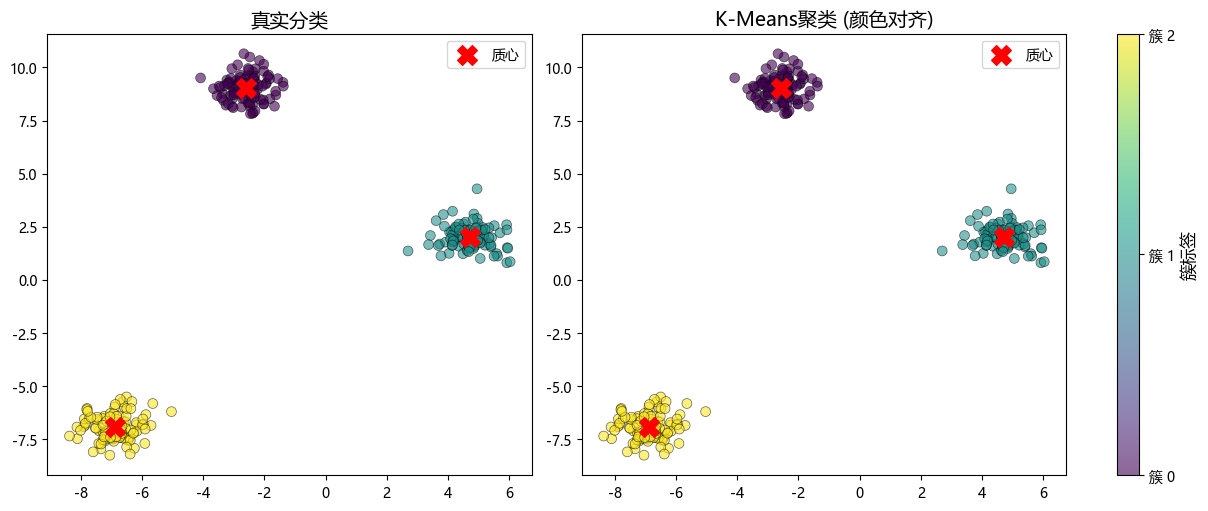

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from scipy.optimize import linear_sum_assignment

# 辅助函数
def get_color_name(label):
    """获取标签对应的颜色名称"""
    colors = {0: '紫色', 1: '蓝绿色', 2: '黄色'}
    return colors.get(label, '未知')

def align_labels(y_true, y_pred, centroids):
    """使用匈牙利算法重新映射预测标签，使其与真实标签的颜色对应"""
    n_clusters = len(np.unique(y_true))
    
    # 构建混淆矩阵
    confusion_matrix = np.zeros((n_clusters, n_clusters), dtype=int)
    for i in range(n_clusters):
        for j in range(n_clusters):
            confusion_matrix[i, j] = np.sum((y_true == i) & (y_pred == j))
    
    # 找到最佳匹配
    row_ind, col_ind = linear_sum_assignment(-confusion_matrix)
    
    # 创建映射字典
    mapping = {j: i for i, j in zip(row_ind, col_ind)}
    
    # 应用映射
    y_pred_aligned = np.array([mapping[label] for label in y_pred])
    
    # 对齐质心
    centroids_aligned = np.zeros_like(centroids)
    for i in range(n_clusters):
        centroids_aligned[mapping[i]] = centroids[i]
    
    return y_pred_aligned, centroids_aligned, mapping

# 1. 生成测试数据
print("="*50)
print("生成测试数据")
print("="*50)

X, y_true = make_blobs(n_samples=300, centers=3, 
                       cluster_std=0.60, random_state=42)

# 2. 训练K-Means模型
print("\n训练K-Means模型...")
kmeans = KMeans(n_clusters=3, 
                init='k-means++',       
                n_init=10,              
                max_iter=300,           
                random_state=42)

kmeans.fit(X)
y_pred_original = kmeans.labels_
n_iter = kmeans.n_iter_

# 3. 对齐标签
print("\n对齐标签颜色...")
y_pred_aligned, centroids_aligned, label_mapping = align_labels(
    y_true, y_pred_original, kmeans.cluster_centers_
)

print(f"标签映射关系: {label_mapping}")
print(f"映射前预测标签分布: {np.bincount(y_pred_original)}")
print(f"映射后预测标签分布: {np.bincount(y_pred_aligned)}")


# 简洁版 - 只显示两幅对比图（没有图例子图）
def plot_comparison_constrained(X, y_true, y_pred_aligned, centroids_aligned):
    """使用 constrained_layout 自动处理布局"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), 
                                   constrained_layout=True)  # 关键参数
    
    vmin, vmax = 0, 2
    cmap = plt.cm.viridis
    
    # 左图
    ax1.scatter(X[:, 0], X[:, 1], c=y_true, cmap=cmap, vmin=vmin, vmax=vmax, 
                alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    ax1.scatter(centroids_aligned[:, 0], centroids_aligned[:, 1], 
               c='red', marker='X', s=200, label='质心')
    ax1.set_title('真实分类', fontsize=14)
    ax1.legend()
    
    # 右图
    im = ax2.scatter(X[:, 0], X[:, 1], c=y_pred_aligned, cmap=cmap, 
                     vmin=vmin, vmax=vmax, alpha=0.6, s=50, 
                     edgecolors='black', linewidth=0.5)
    ax2.scatter(centroids_aligned[:, 0], centroids_aligned[:, 1], 
               c='red', marker='X', s=200, label='质心')
    ax2.set_title('K-Means聚类 (颜色对齐)', fontsize=14)
    ax2.legend()
    
    # 添加颜色条 - constrained_layout 会自动调整空间
    cbar = fig.colorbar(im, ax=[ax1, ax2], orientation='vertical', 
                       fraction=0.05, pad=0.05)
    cbar.set_label('簇标签', fontsize=12)
    cbar.set_ticks([0, 1, 2])
    cbar.set_ticklabels(['簇 0', '簇 1', '簇 2'])
    
    # 不需要 tight_layout()
    plt.show()

# 使用
plot_comparison_constrained(X, y_true, y_pred_aligned, centroids_aligned)




## K-Means 的核心思想

**一句话概括**：K-Means 是一种"物以类聚"的算法——它试图找到数据的 K 个"中心点"，然后把每个数据点分配给离它最近的中心，从而形成 K 个簇（cluster）。

## 生活中的类比

想象你是一个大型图书馆的管理员，要把散落在房间里的书分成 3 堆：

**第1步**：你随机选择 3 本书作为"代表"（初始中心）
**第2步**：每本书都去离自己最近的"代表"那里集合（分配）
**第3步**：每一堆书里，你找出那堆书的"平均位置"，把代表移动到那里（更新中心）
**第4步**：重复第2-3步，直到代表位置不再变化

这就是 K-Means 的完整过程。

## 数学本质

K-Means 在做一件什么事情？它在**最小化一个目标函数**：

**簇内平方和（Within-Cluster Sum of Squares）** = 每个点到其所属簇中心的距离平方之和

```
目标 = 最小化 Σ(所有点到其簇中心的距离²)
```


## 为什么叫 K-Means？

- **K**：你要分成的簇的数量（需要预先指定）
- **Means**：均值。每个簇的中心是簇内所有点的**均值**（平均位置）

## 算法步骤（纯逻辑描述）

假设你有 N 个点，想分成 K 个簇：

```mermaid
graph TD
    A[开始] --> B[随机选择 K 个点作为初始中心]
    B --> C[每个点分配到最近的中心]
    C --> D[重新计算每个簇的中心位置<br/>取簇内所有点的平均值]
    D --> E{中心位置是否变化？}
    E -->|是| C
    E -->|否| F[结束，输出聚类结果]
```

## 一个直观的例子

想象二维平面上有很多点，肉眼可以看出大概有 3 个群体：

**第1轮**：随机选 3 个点作为中心（可能选得很差，比如都选在同一个群体里）
**分配**：所有点都去最近的中心 → 结果很差，有些群体被拆散了
**更新**：计算每堆点的平均值，移动中心位置
**第2轮**：中心移动后，点重新分配 → 结果改善
**第3轮**：继续迭代...
**收敛**：中心不再移动，每个簇稳定了下来

## 关键概念解释

### 1. "距离"是什么？
通常使用**欧氏距离**（直线距离）。两点越近，数字越小。

### 2. "中心"是什么？
不是原本存在的点，而是**计算出来的虚拟点**。它是簇内所有点的"平均位置"——就像找出 5 个小孩的"平均身高"一样，可能碰巧等于某个孩子的身高，也可能不是。

### 3. "收敛"是什么意思？
当簇的中心不再移动（或者移动非常小），算法就停止了。这表示找到了相对稳定的分组。

## K-Means 的优缺点

**优点**：
- 简单直观，容易理解
- 速度快，适合大数据集
- 结果容易解释

**缺点**：
- 需要预先告诉算法"应该分几堆"（*K* 值）
- 对初始位置敏感（第一次选中心很重要）
- 假设簇是圆形的，无法处理复杂形状（比如月牙形）
- 对*异常值*敏感（一个离群点可能拉偏整个簇）

## 为什么需要多次运行？

因为初始中心是**随机**选的。选得好，很快找到好的聚类；选得差，可能卡在不好的结果。所以通常做法是：运行 10 次，选结果最好的那一次。

## 如何选择 K 值？

这是 K-Means 最大的痛点。常用方法：

**肘部法则**：尝试不同的 K，画出"K 值 vs 簇内距离"曲线。曲线会出现一个"肘部"转折点，那里就是比较合适的 K。

- K=1 时，所有点一个簇，距离很大
- K 增加，距离会下降
- 但 K 太大，每个簇只有一个点，距离为 0（没意义）
- 在某个 K 之后，距离下降的速度变缓，这个转折点就是"肘部"

## 总结

K-Means 的核心就是**迭代优化**：
1. 猜中心
2. 分配点
3. 重新计算中心
4. 重复直到稳定

**K**值就是你想把数据分成**几个簇**（几堆/几群）